# L2 Cache 吞吐量对比图

以负载情况（TP:AP比例）为横坐标，显示TP和AP在L2 ON/OFF下的吞吐量对比


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持 - 使用系统中实际存在的中文字体
plt.rcParams['font.sans-serif'] = ['AR PL UKai CN', 'AR PL UMing CN', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline


In [2]:
# 加载数据
df = pd.read_csv('results/batch_l2_tests/l2_batch_summary.csv')

# 转换数值列
df['l2_on_tp_tps'] = pd.to_numeric(df['l2_on_tp_tps'], errors='coerce')
df['l2_off_tp_tps'] = pd.to_numeric(df['l2_off_tp_tps'], errors='coerce')
df['l2_on_ap_qps'] = pd.to_numeric(df['l2_on_ap_qps'], errors='coerce')
df['l2_off_ap_qps'] = pd.to_numeric(df['l2_off_ap_qps'], errors='coerce')

# 按TP:AP比例排序
df_chart = df.sort_values('tp_ap_ratio')
x_pos = range(len(df_chart))

print(f'加载了 {len(df_chart)} 组测试数据')
print(f'负载比例: {df_chart["tp_ap_ratio"].tolist()}')


加载了 7 组测试数据
负载比例: ['10:6', '12:4', '4:12', '6:10', '8:8', '8:8', '8:8']


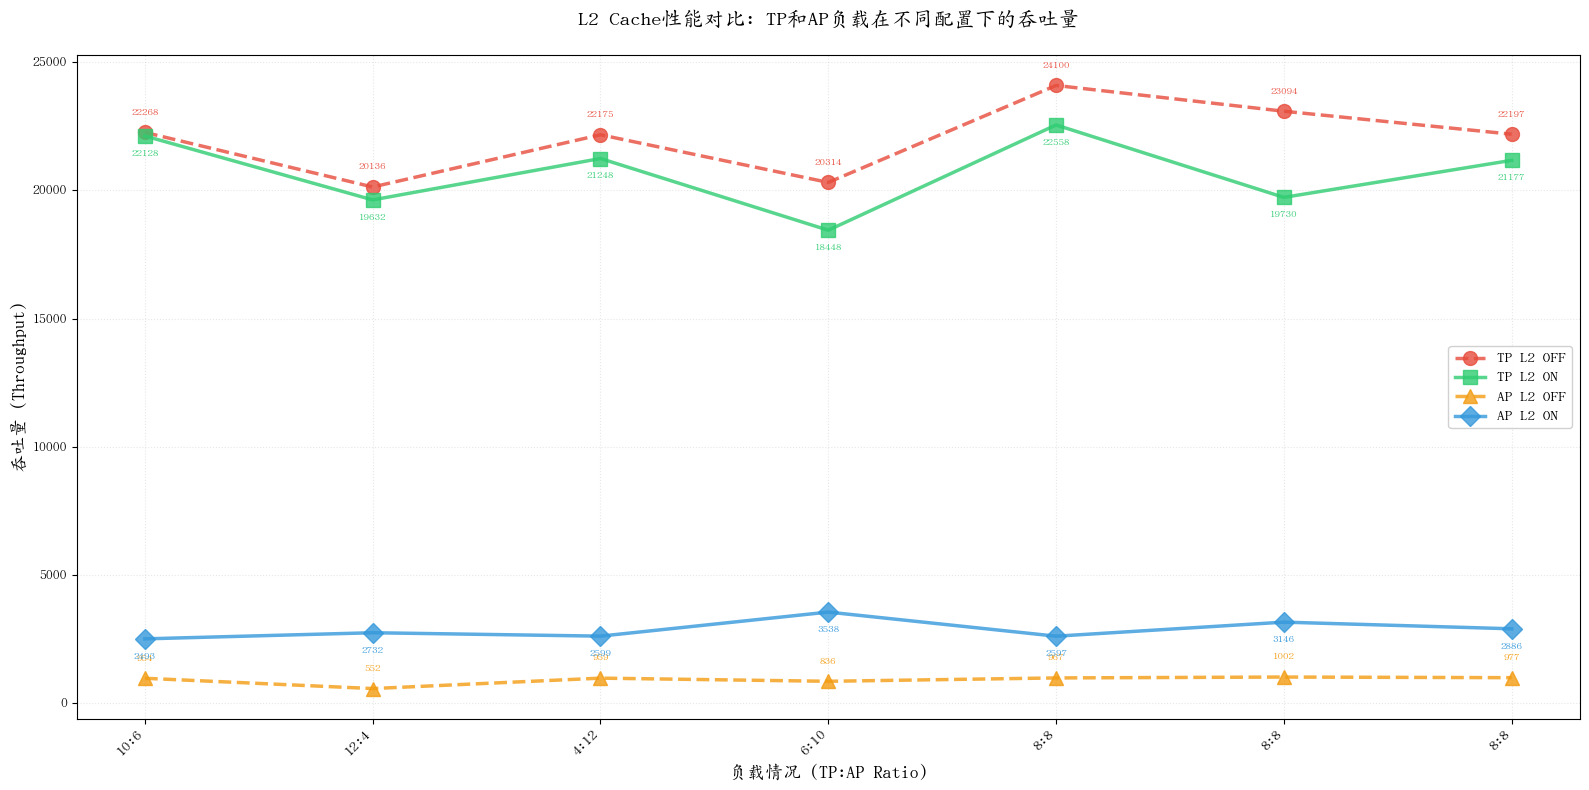

In [ ]:
# 绘制组合吞吐量对比图
fig, ax = plt.subplots(figsize=(16, 8))

# 绘制四条折线
ax.plot(x_pos, df_chart['l2_off_tp_tps'], marker='o', linewidth=2.5, markersize=10, 
         label='TP L2 OFF', color='#e74c3c', linestyle='--', alpha=0.8)
ax.plot(x_pos, df_chart['l2_on_tp_tps'], marker='s', linewidth=2.5, markersize=10, 
         label='TP L2 ON', color='#2ecc71', linestyle='-', alpha=0.8)
ax.plot(x_pos, df_chart['l2_off_ap_qps'], marker='^', linewidth=2.5, markersize=10, 
         label='AP L2 OFF', color='#f39c12', linestyle='--', alpha=0.8)
ax.plot(x_pos, df_chart['l2_on_ap_qps'], marker='D', linewidth=2.5, markersize=10, 
         label='AP L2 ON', color='#3498db', linestyle='-', alpha=0.8)

# 设置x轴
ax.set_xticks(x_pos)
ax.set_xticklabels(df_chart['tp_ap_ratio'], rotation=45, ha='right', fontsize=11)
ax.set_xlabel('负载情况 (TP:AP Ratio)', fontsize=13, fontweight='bold')
ax.set_ylabel('吞吐量 (Throughput)', fontsize=13, fontweight='bold')
ax.set_title('L2 Cache性能对比: TP和AP负载在不同配置下的吞吐量', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle=':')

# 添加数值标签（仅对非零值）
for i in range(len(df_chart)):
    # TP L2 OFF
    if not pd.isna(df_chart.iloc[i]['l2 off_tp_tps']) and df_chart.iloc[i]['l2_off_tp_tps'] > 0:
        ax.annotate(f"{int(df_chart.iloc[i]['l2_off_tp_tps'])}", 
                    (i, df_chart.iloc[i]['l2_off_tp_tps']), 
                    textcoords='offset points', xytext=(0,12), ha='center', 
                    fontsize=8, color='#e74c3c', fontweight='bold')
    # TP L2 ON
    if not pd.isna(df_chart.iloc[i]['l2_on_tp_tps']) and df_chart.iloc[i]['l2_on_tp_tps'] > 0:
        ax.annotate(f"{int(df_chart.iloc[i]['l2_on_tp_tps'])}", 
                    (i, df_chart.iloc[i]['l2_on_tp_tps']), 
                    textcoords='offset points', xytext=(0,-15), ha='center', 
                    fontsize=8, color='#2ecc71', fontweight='bold')
    # AP L2 OFF
    if not pd.isna(df_chart.iloc[i]['l2_off_ap_qps']) and df_chart.iloc[i]['l2_off_ap_qps'] > 0:
        ax.annotate(f"{int(df_chart.iloc[i]['l2_off_ap_qps'])}", 
                    (i, df_chart.iloc[i]['l2_off_ap_qps']), 
                    textcoords='offset points', xytext=(0,12), ha='center', 
                    fontsize=8, color='#f39c12', fontweight='bold')
    # AP L2 ON
    if not pd.isna(df_chart.iloc[i]['l2_on_ap_qps']) and df_chart.iloc[i]['l2_on_ap_qps'] > 0:
        ax.annotate(f"{int(df_chart.iloc[i]['l2_on_ap_qps'])}", 
                    (i, df_chart.iloc[i]['l2_on_ap_qps']), 
                    textcoords='offset points', xytext=(0,-15), ha='center', 
                    fontsize=8, color='#3498db', fontweight='bold')

plt.tight_layout()
plt.show()
